# Hermite interpolation accuracy

This notebook tests the accuracy of Hermite interpolation for satellite orbit data.

The original 60-second orbit solution is artificially thinned to longer input intervals.
The removed midpoints are then reconstructed by interpolation and compared with the original values.

## Imports

Load standard libraries, third-party packages, and functions from the local `doris` package.

In [1]:
# --- Standard library ---
import sys                                # system-specific parameters
from pathlib import Path                  # filesystem paths
from datetime import date                 # date handling

# --- Third-party packages ---
try:
    import numpy as np                    # numerical arrays
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with:\n  pip install numpy") from e

try:
    import pandas as pd                   # tabular dataframes
    pd.set_option("display.float_format", "{:.5f}".format)
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt       # plotting
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with:\n  pip install matplotlib") from e

try:
    from scipy.interpolate import PchipInterpolator  # shape-preserving interpolation
    from scipy.signal import lombscargle             # periodogram
except ImportError as e:
    raise RuntimeError("Missing dependency: 'scipy'. Install it with:\n  pip install scipy") from e

# --- doris package ---
_src = Path("../../src").resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.orbits import (
        compare_trajectories,
        iter_orbit_days,
        orbit_diff_stats,
    )
    from doris.analysis.orbits.interpolate.hermite import hermite_at_time

except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from the expected directory."
    ) from e

## Paths and parameters

Set the input orbit directory, tested satellite, time interval, and Hermite interpolation settings.

In [2]:
# --- Dataset selection ---
SATELLITE = "srl"

# --- Project paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_ROOT = PROJECT_ROOT / "data"

# --- Input data ---
SOLUTION_ROOT = DATA_ROOT / "orbits" / "gop"
TESTED_DATA = SOLUTION_ROOT / SATELLITE

# --- LaTeX export paths ---
LATEX_ROOT = PROJECT_ROOT / "LaTeX"

IMAGES_DIR = LATEX_ROOT / "images" / "test" / "hermite_precision" / SOLUTION_ROOT.name / SATELLITE
TABLES_DIR = LATEX_ROOT / "tables" / "test" / "hermite_precision" / SOLUTION_ROOT.name / SATELLITE

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Time interval ---
START_DATE = date(2024, 1, 1)
END_DATE   = date(2024, 1, 30)

# --- Interpolation setup ---
HERMITE_DEGREE = 11
EDGE_TRIM = 15

# keep_every = 2 means input interval 120 s
KEEP_EVERY_LIST = [2, 4, 6, 8]

# --- Debug prints ---
print("PROJECT_ROOT:", PROJECT_ROOT)
print("TESTED_DATA: ", TESTED_DATA)
print("EXISTS:      ", TESTED_DATA.exists())
print("IMAGES_DIR:  ", IMAGES_DIR)
print("TABLES_DIR:  ", TABLES_DIR)
print("DEGREE:      ", HERMITE_DEGREE)
print("INTERVALS [s]:", [k * 60 for k in KEEP_EVERY_LIST])

PROJECT_ROOT: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
TESTED_DATA:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\orbits\gop\srl
EXISTS:       True
IMAGES_DIR:   C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\test\hermite_precision\gop\srl
TABLES_DIR:   C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\test\hermite_precision\gop\srl
DEGREE:       11
INTERVALS [s]: [120, 240, 360, 480]


## Load one test day

Load the first available day only to check that the input data can be read correctly.

In [3]:
for test_day, test_df in iter_orbit_days(TESTED_DATA, START_DATE, END_DATE):
    break

print("Test day:", test_day)
display(test_df.head())

Test day: 2024-01-01


,MJD_TAI,x,y,z,vx,vy,vz,source_file
0,60310.00022,-785415.24900,3911866.47300,-5957896.18800,1061.55346,6294.25799,3996.29928,GOP_srl_240101_240101_V99.sp3
1,60310.00091,-718618.52600,4281441.16900,-5706687.95600,1163.89207,6020.76486,4374.62119,GOP_srl_240101_240101_V99.sp3
2,60310.00161,-645887.66900,4633873.38200,-5433278.71500,1259.25840,5723.03163,4736.09185,GOP_srl_240101_240101_V99.sp3
3,60310.00230,-567658.56400,4967743.82500,-5138722.32800,1347.07366,5402.24494,5079.29525,GOP_srl_240101_240101_V99.sp3
4,60310.00300,-484400.67400,5281707.30400,-4824155.66800,1426.79799,5059.68769,5402.88183,GOP_srl_240101_240101_V99.sp3


## Prepare one day

In [4]:
def prepare_day_df(df_day):
    df_day = df_day.copy().sort_values("MJD_TAI").reset_index(drop=True)

    t0 = df_day["MJD_TAI"].iloc[0]
    df_day["t_sec"] = (df_day["MJD_TAI"] - t0) * 86400.0

    return df_day

# quick test
test_df = prepare_day_df(test_df)
display(test_df.head())

,MJD_TAI,x,y,z,vx,vy,vz,source_file,t_sec
0,60310.00022,-785415.24900,3911866.47300,-5957896.18800,1061.55346,6294.25799,3996.29928,GOP_srl_240101_240101_V99.sp3,0.00000
1,60310.00091,-718618.52600,4281441.16900,-5706687.95600,1163.89207,6020.76486,4374.62119,GOP_srl_240101_240101_V99.sp3,60.00000
2,60310.00161,-645887.66900,4633873.38200,-5433278.71500,1259.25840,5723.03163,4736.09185,GOP_srl_240101_240101_V99.sp3,120.00000
3,60310.00230,-567658.56400,4967743.82500,-5138722.32800,1347.07366,5402.24494,5079.29525,GOP_srl_240101_240101_V99.sp3,180.00000
4,60310.00300,-484400.67400,5281707.30400,-4824155.66800,1426.79799,5059.68769,5402.88183,GOP_srl_240101_240101_V99.sp3,240.00000


## Check regular sampling

In [5]:
def check_regular_sampling(df_day):
    dt = df_day["t_sec"].diff().dropna().to_numpy()

    if not np.all(np.abs(dt - 60.0) < 1e-6):
        raise ValueError("Sampling is not regular 60 s.")


# quick test
check_regular_sampling(test_df)
print("sampling OK")

sampling OK


## Thin one day

In [6]:
def build_test_set(df_day, keep_every):
    # points to keep
    src_df = df_day.iloc[::keep_every].copy().reset_index(drop=True)

    # points in between
    truth_idx = np.arange(keep_every // 2, len(df_day), keep_every)

    # discard edge points to avoid interpolation failure
    truth_idx = truth_idx[EDGE_TRIM:-EDGE_TRIM]

    truth_df = df_day.iloc[truth_idx].copy().reset_index(drop=True)

    return src_df, truth_df


# quick test
src_df, truth_df = build_test_set(test_df, keep_every=2)
display(src_df.head())
display(truth_df.head())

,MJD_TAI,x,y,z,vx,vy,vz,source_file,t_sec
0,60310.00022,-785415.24900,3911866.47300,-5957896.18800,1061.55346,6294.25799,3996.29928,GOP_srl_240101_240101_V99.sp3,0.00000
1,60310.00161,-645887.66900,4633873.38200,-5433278.71500,1259.25840,5723.03163,4736.09185,GOP_srl_240101_240101_V99.sp3,120.00000
2,60310.00300,-484400.67400,5281707.30400,-4824155.66800,1426.79799,5059.68769,5402.88183,GOP_srl_240101_240101_V99.sp3,240.00000
3,60310.00439,-304829.52200,5844936.66500,-4139928.69800,1560.02719,4314.84581,5986.17275,GOP_srl_240101_240101_V99.sp3,360.00000
4,60310.00578,-111504.77100,6314488.72900,-3391186.31600,1655.51748,3500.50481,6476.70777,GOP_srl_240101_240101_V99.sp3,480.00000


,MJD_TAI,x,y,z,vx,vy,vz,source_file,t_sec
0,60310.02175,1534724.53400,4030458.57500,5709546.80300,-42.41386,-6165.70484,4353.64278,GOP_srl_240101_240101_V99.sp3,1860.00000
1,60310.02314,1511095.79300,3261354.48000,6185968.08600,-352.24709,-6635.15759,3576.38898,GOP_srl_240101_240101_V99.sp3,1980.00000
2,60310.02453,1450115.62600,2442365.76800,6565652.11100,-663.81605,-6996.04558,2743.46183,GOP_srl_240101_240101_V99.sp3,2100.00000
3,60310.02591,1351981.33100,1586868.42200,6842691.94300,-970.35041,-7242.87488,1867.88097,GOP_srl_240101_240101_V99.sp3,2220.00000
4,60310.02730,1217703.71200,708785.05900,7012782.58600,-1265.08466,-7372.03653,963.29015,GOP_srl_240101_240101_V99.sp3,2340.00000


## Interpolate test

In [7]:
def interpolate(src_df, truth_df):
    m = np.column_stack([
        src_df["t_sec"].to_numpy(),
        src_df[["x", "y", "z"]].to_numpy(),
        src_df[["vx", "vy", "vz"]].to_numpy(),
    ])

    t = truth_df["t_sec"].to_numpy()
    r_true = truth_df[["x", "y", "z"]].to_numpy()

    r_int = hermite_at_time(m, t, degree=HERMITE_DEGREE)
    err = (r_int - r_true) * 1000.0

    return err


# quick test
err = interpolate(src_df, truth_df)
print(err[:5])

[[-0.27782004 -1.38726644  1.16837677]
 [ 0.70096506  0.88904845 -0.64875837]
 [-0.02195407  1.68587919 -1.2045633 ]
 [-0.06728503 -2.34547118  0.87381434]
 [ 0.24160161  0.94979105  0.12131594]]


## Compare test set

In [8]:
def compare_test_set(src_df, truth_df):
    diff = compare_trajectories(
        src_df,
        truth_df,
        time_col="t_sec",
        degree=HERMITE_DEGREE,
        edge_trim=EDGE_TRIM,
        rtn=True,
        unit="m",
    )

    return diff


# quick test
diff = compare_test_set(src_df, truth_df)
display(diff.head())

,t_sec,x_ref,y_ref,z_ref,x_interp,y_interp,z_interp,dx_m,dy_m,dz_m,norm_m,dR_m,dT_m,dN_m
0,1860.00000,1534724.53400,4030458.57500,5709546.80300,1534724.53372,4030458.57361,5709546.80417,0.00028,0.00139,-0.00117,0.00183,-0.00009,-0.00181,0.00029
1,1980.00000,1511095.79300,3261354.48000,6185968.08600,1511095.79370,3261354.48089,6185968.08535,-0.00070,-0.00089,0.00065,0.00130,0.00001,0.00112,-0.00067
2,2100.00000,1450115.62600,2442365.76800,6565652.11100,1450115.62598,2442365.76969,6565652.10980,0.00002,-0.00169,0.00120,0.00207,0.00053,0.00200,0.00009
3,2220.00000,1351981.33100,1586868.42200,6842691.94300,1351981.33093,1586868.41965,6842691.94387,0.00007,0.00235,-0.00087,0.00250,-0.00030,-0.00248,-0.00020
4,2340.00000,1217703.71200,708785.05900,7012782.58600,1217703.71224,708785.05995,7012782.58612,-0.00024,-0.00095,-0.00012,0.00099,-0.00025,0.00095,-0.00004


## Run interpolation precision test

Loop over all selected days and input intervals.
For each case, compute RTN interpolation differences and daily statistics.

In [9]:
results = {}
stats_rows = []

for day, df_day in iter_orbit_days(TESTED_DATA, START_DATE, END_DATE):
    print(f"\nDAY: {day}")

    df_day = prepare_day_df(df_day)
    check_regular_sampling(df_day)

    for keep_every in KEEP_EVERY_LIST:
        print(f"  keep_every = {keep_every}")

        src_df, truth_df = build_test_set(df_day, keep_every)
        diff = compare_test_set(src_df, truth_df)

        # store detailed point-wise results
        results[(day, keep_every)] = diff

        stats = orbit_diff_stats(diff)
        stats["day"] = day
        stats["keep_every"] = keep_every
        stats_rows.append(stats)

print(f"\nZpracováno: {len(stats_rows)} kombinací den × keep_every")
print(f"Uloženo detailních diffů: {len(results)}")


DAY: 2024-01-01
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-02
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-03
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-04
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-05
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-06
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-07
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-08
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-09
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-10
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-11
  keep_every = 2
  keep_every = 4
  keep_every = 6
  keep_every = 8

DAY: 2024-01-12
  keep_every = 2
  keep_every = 4
  keep_every =

## Inspect results

In [10]:
print("Počet kombinací day × keep_every:", len(results))
print("Počet denních statistik:", len(stats_rows))

print("\nPrvních pár klíčů v results:")
for i, key in enumerate(results.keys()):
    print(key)
    if i == 4:
        break

first_key = list(results.keys())[0]
print("\nUkázka jednoho detailního diff dataframe:")
print("KEY:", first_key)
display(results[first_key].head())

results_df = pd.DataFrame(stats_rows)

print("\nSloupce v results_df:")
print(list(results_df.columns))

print("\nUkázka denních statistik:")
display(results_df.head())

EXPORT_DIR = TESTED_DATA / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(EXPORT_DIR / "results_df.csv", index=False, sep=";", encoding="utf-8-sig")

Počet kombinací day × keep_every: 120
Počet denních statistik: 120

Prvních pár klíčů v results:
(datetime.date(2024, 1, 1), 2)
(datetime.date(2024, 1, 1), 4)
(datetime.date(2024, 1, 1), 6)
(datetime.date(2024, 1, 1), 8)
(datetime.date(2024, 1, 2), 2)

Ukázka jednoho detailního diff dataframe:
KEY: (datetime.date(2024, 1, 1), 2)


,t_sec,x_ref,y_ref,z_ref,x_interp,y_interp,z_interp,dx_m,dy_m,dz_m,norm_m,dR_m,dT_m,dN_m
0,1860.00000,1534724.53400,4030458.57500,5709546.80300,1534724.53372,4030458.57361,5709546.80417,0.00028,0.00139,-0.00117,0.00183,-0.00009,-0.00181,0.00029
1,1980.00000,1511095.79300,3261354.48000,6185968.08600,1511095.79370,3261354.48089,6185968.08535,-0.00070,-0.00089,0.00065,0.00130,0.00001,0.00112,-0.00067
2,2100.00000,1450115.62600,2442365.76800,6565652.11100,1450115.62598,2442365.76969,6565652.10980,0.00002,-0.00169,0.00120,0.00207,0.00053,0.00200,0.00009
3,2220.00000,1351981.33100,1586868.42200,6842691.94300,1351981.33093,1586868.41965,6842691.94387,0.00007,0.00235,-0.00087,0.00250,-0.00030,-0.00248,-0.00020
4,2340.00000,1217703.71200,708785.05900,7012782.58600,1217703.71224,708785.05995,7012782.58612,-0.00024,-0.00095,-0.00012,0.00099,-0.00025,0.00095,-0.00004



Sloupce v results_df:
['R_mean', 'T_mean', 'N_mean', 'R_rms', 'T_rms', 'N_rms', 'R_rms0', 'T_rms0', 'N_rms0', 'day', 'keep_every']

Ukázka denních statistik:


,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0,day,keep_every
0,-0.00002,0.00002,-0.00000,0.00036,0.00156,0.00037,0.00036,0.00156,0.00037,2024-01-01,2
1,0.00003,0.00118,-0.00001,0.00548,0.00612,0.00180,0.00548,0.00601,0.00180,2024-01-01,4
2,0.00009,0.00034,0.00064,0.03818,0.03272,0.01136,0.03818,0.03272,0.01134,2024-01-01,6
3,-0.01059,-0.01531,0.00284,0.10711,0.12000,0.03618,0.10658,0.11902,0.03607,2024-01-01,8
4,-0.00005,0.00001,0.00001,0.00036,0.00155,0.00036,0.00036,0.00155,0.00036,2024-01-02,2


## RTN Daily statistics

Create a dataframe with RTN daily statistics

In [11]:
results_df = pd.DataFrame(stats_rows)
results_df["interval_s"] = results_df["keep_every"]*60
display(results_df)

,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0,day,keep_every,interval_s
0,-0.00002,0.00002,-0.00000,0.00036,0.00156,0.00037,0.00036,0.00156,0.00037,2024-01-01,2,120
1,0.00003,0.00118,-0.00001,0.00548,0.00612,0.00180,0.00548,0.00601,0.00180,2024-01-01,4,240
2,0.00009,0.00034,0.00064,0.03818,0.03272,0.01136,0.03818,0.03272,0.01134,2024-01-01,6,360
3,-0.01059,-0.01531,0.00284,0.10711,0.12000,0.03618,0.10658,0.11902,0.03607,2024-01-01,8,480
4,-0.00005,0.00001,0.00001,0.00036,0.00155,0.00036,0.00036,0.00155,0.00036,2024-01-02,2,120
...,...,...,...,...,...,...,...,...,...,...,...,...
115,-0.02363,0.00833,-0.00877,0.11804,0.10570,0.04143,0.11565,0.10537,0.04050,2024-01-29,8,480
116,-0.00004,-0.00000,-0.00000,0.00035,0.00157,0.00037,0.00034,0.00157,0.00037,2024-01-30,2,120
117,-0.00078,-0.00087,0.00008,0.00556,0.00576,0.00176,0.00551,0.00570,0.00175,2024-01-30,4,240
118,0.00127,0.00153,0.00096,0.03564,0.03418,0.01020,0.03561,0.03415,0.01016,2024-01-30,6,360


## Daily RTN graph

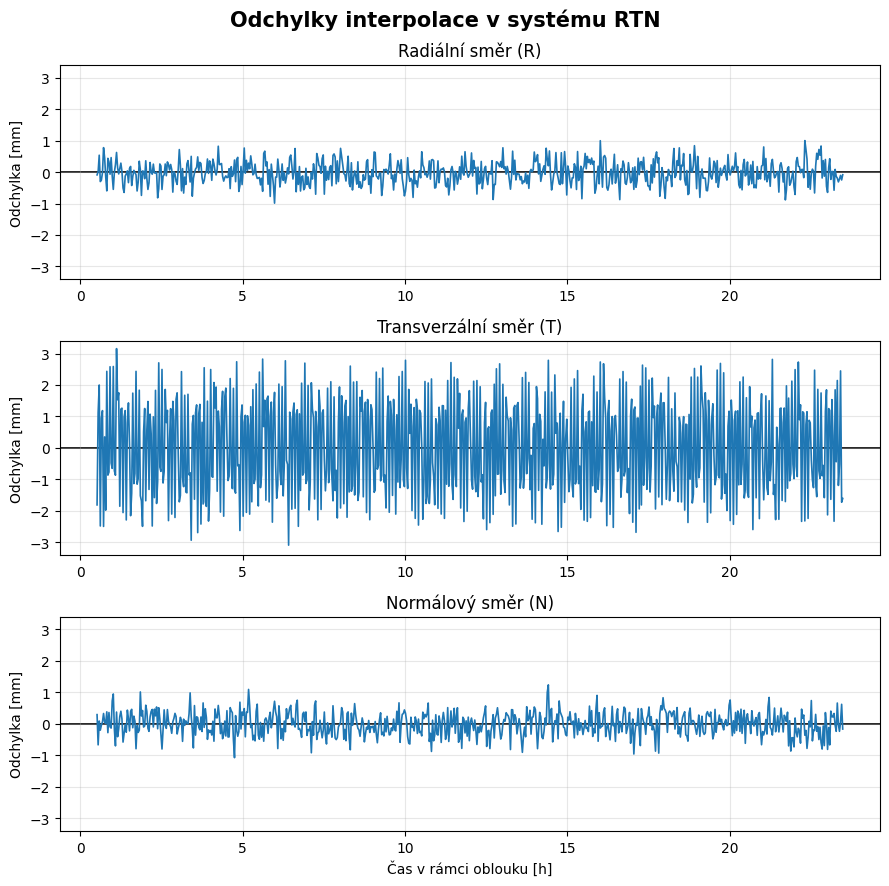

In [12]:
SELECT_KEEP_EVERY = 2

selected_keys = [k for k in results.keys() if k[1] == SELECT_KEEP_EVERY]
selected_keys = sorted(selected_keys, key=lambda x: x[0])
day, keep_every = selected_keys[0]

df = results[(day, keep_every)]

# convert to hours
t_hours = df["t_sec"] / 3600

# figure size = indirectly also subplot size
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR_m", "Radiální směr (R)"),
    ("dT_m", "Transverzální směr (T)"),
    ("dN_m", "Normálový směr (N)"),
]

# data v mm
vals_all = df[["dR_m", "dT_m", "dN_m"]].values * 1000
max_abs = np.max(np.abs(vals_all))

# actual axis range with small margin
margin = 0.25
ylim = (-max_abs - margin, max_abs + margin)

# popisky osy jen do ±3 mm
y_ticks = np.arange(-3, 4, 1)

for ax, (col, title) in zip(axes, components):
    vals = df[col].values * 1000
    ax.plot(t_hours, vals, linewidth=1.2)
    ax.axhline(0, color="black", linewidth=1.2, zorder=0)

    ax.set_ylabel("Odchylka [mm]")
    ax.set_title(title)
    ax.set_ylim(ylim)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Čas v rámci oblouku [h]")

fig.suptitle("Odchylky interpolace v systému RTN", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RTN_differences_single_day.pdf", bbox_inches="tight")
plt.show()

## Daily RTN histogram

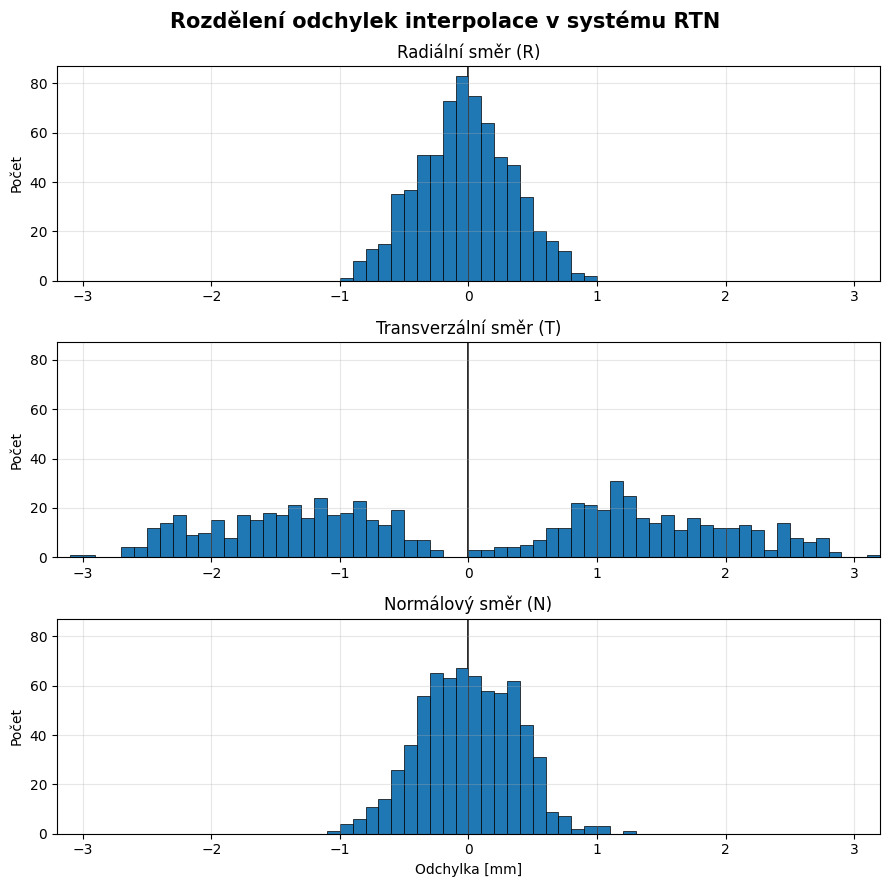

In [13]:
SELECT_KEEP_EVERY = 2

selected_keys = [k for k in results.keys() if k[1] == SELECT_KEEP_EVERY]
selected_keys = sorted(selected_keys, key=lambda x: x[0])
day, keep_every = selected_keys[0]

df = results[(day, keep_every)]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR_m", "Radiální směr (R)"),
    ("dT_m", "Transverzální směr (T)"),
    ("dN_m", "Normálový směr (N)"),
]

# rozsah a biny
vals_all = df[["dR_m", "dT_m", "dN_m"]].values * 1000
max_abs = np.max(np.abs(vals_all))
xmax = np.ceil(max_abs * 10) / 10
bins = np.arange(-xmax, xmax + 0.1, 0.1)

for ax, (col, title) in zip(axes, components):
    vals = df[col].values * 1000
    ax.hist(vals, bins=bins, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2, zorder=0)
    ax.set_ylabel("Počet")
    ax.set_title(title)
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Odchylka [mm]")

fig.suptitle(f"Rozdělení odchylek interpolace v systému RTN", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RTN_histogram_single_day.pdf", bbox_inches="tight")
plt.show()

## Daily RTN periodograms

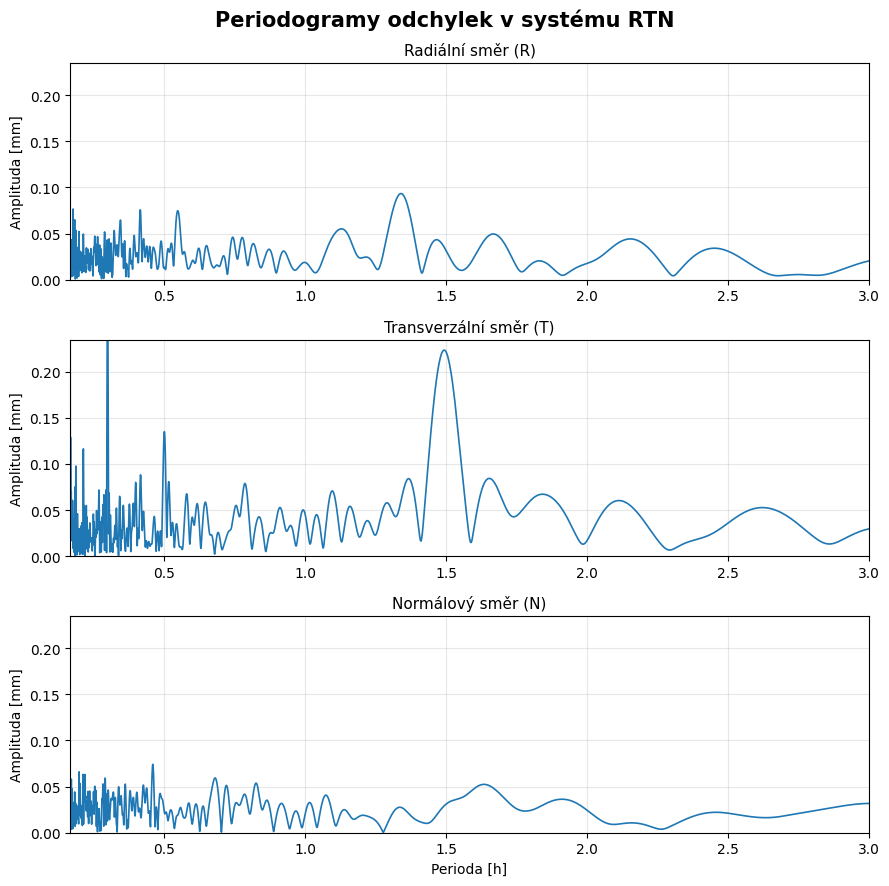

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lombscargle

SELECT_KEEP_EVERY = 2

selected_keys = [k for k in results.keys() if k[1] == SELECT_KEEP_EVERY]
selected_keys = sorted(selected_keys, key=lambda x: x[0])
day, keep_every = selected_keys[0]

df = results[(day, keep_every)]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR_m", "Radiální směr (R)"),
    ("dT_m", "Transverzální směr (T)"),
    ("dN_m", "Normálový směr (N)"),
]

# time
t = df["t_sec"].values
N = len(t)

# frekvence → periody
f_min = 1 / (3 * 3600)
f_max = 1 / (10 * 60)

frequencies = np.linspace(f_min, f_max, 5000)
angular_freq = 2 * np.pi * frequencies
periods = 1 / frequencies / 3600  # hodiny

# maska jen pro periody > 0.5 h
mask = periods > 0.5

periodograms = {}
global_max = 0

for col, _ in components:
    y = df[col].values * 1000  # mm
    y = y - np.mean(y)

    pgram = lombscargle(t, y, angular_freq)

    # convert to amplitude
    amplitude = 2 * np.sqrt(pgram / N)

    periodograms[col] = amplitude

    local_max = np.max(amplitude[mask])
    if local_max > global_max:
        global_max = local_max

# plot
for ax, (col, title) in zip(axes, components):
    amp = periodograms[col]

    ax.plot(periods, amp, linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(periods.min(), periods.max())

fig.suptitle(
    "Periodogramy odchylek v systému RTN",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RTN_lomb_scargle_periodograms_single_day.pdf", bbox_inches="tight")
plt.show()

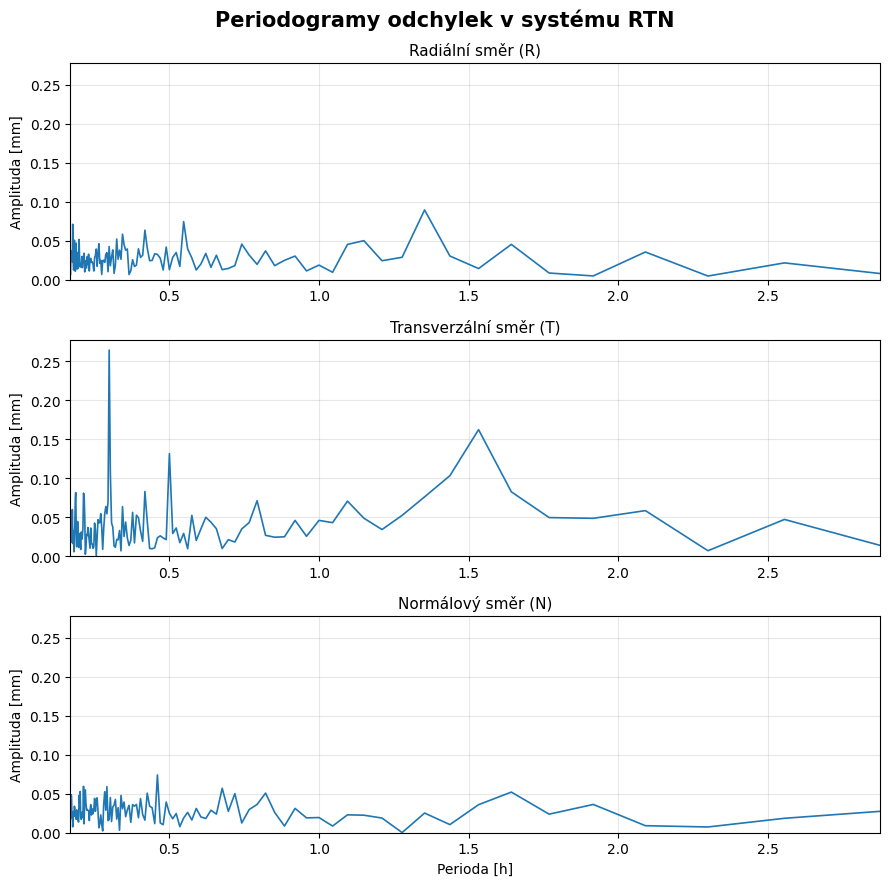

In [15]:
import matplotlib.pyplot as plt

from doris.analysis.spectral import compute_periodogram

SELECT_KEEP_EVERY = 2

selected_keys = [k for k in results.keys() if k[1] == SELECT_KEEP_EVERY]
selected_keys = sorted(selected_keys, key=lambda x: x[0])
day, keep_every = selected_keys[0]

df = results[(day, keep_every)].copy()

components = [
    ("dR_m", "Radiální směr (R)"),
    ("dT_m", "Transverzální směr (T)"),
    ("dN_m", "Normálový směr (N)"),
]

# Convert to mm — compute_periodogram returns amplitude in the same units as input.
for col, _ in components:
    df[f"{col}_mm"] = df[col] * 1000

value_cols = [f"{col}_mm" for col, _ in components]

periodogram = compute_periodogram(
    df,
    method="fft",
    time_col="t_sec",
    value_cols=value_cols,
    min_period=10 * 60,      # 10 min
    max_period=3 * 3600,     # 3 h
)

periodogram["period_h"] = periodogram["period"] / 3600

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

global_max = periodogram["amplitude"].max()

for ax, (col, title) in zip(axes, components):
    comp = f"{col}_mm"
    pg = periodogram[periodogram["component"] == comp]

    ax.plot(pg["period_h"], pg["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(
    periodogram["period_h"].min(),
    periodogram["period_h"].max(),
)

fig.suptitle(
    "Periodogramy odchylek v systému RTN",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RTN_fft_periodograms_single_day.pdf", bbox_inches="tight")
plt.show()

## Daily RTN RMS

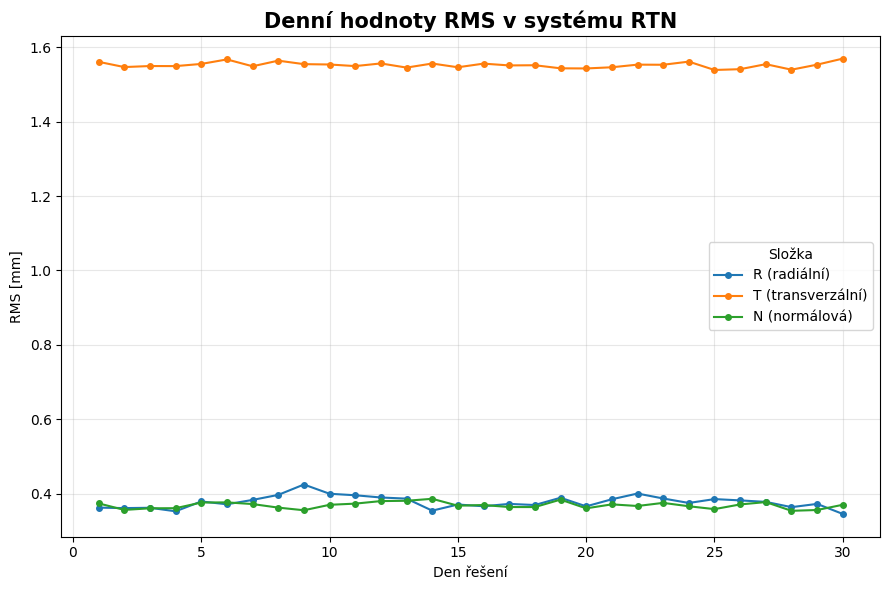

In [16]:
SELECT_INTERVAL_S = 120

plot_df = results_df[results_df["interval_s"] == SELECT_INTERVAL_S].copy()
plot_df = plot_df.sort_values("day").reset_index(drop=True)
plot_df["day_idx"] = plot_df.index + 1

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(plot_df["day_idx"], plot_df["R_rms"] * 1000, "o-", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day_idx"], plot_df["T_rms"] * 1000, "o-", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day_idx"], plot_df["N_rms"] * 1000, "o-", linewidth=1.5, markersize=4, label="N (normálová)")

ax.set_xlabel("Den řešení")
ax.set_ylabel("RMS [mm]")
ax.set_title(f"Denní hodnoty RMS v systému RTN", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(title="Složka")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "Daily_RTN_RMS_over_time.pdf", bbox_inches="tight")
plt.show()

## Daily 3D RMS for intervals

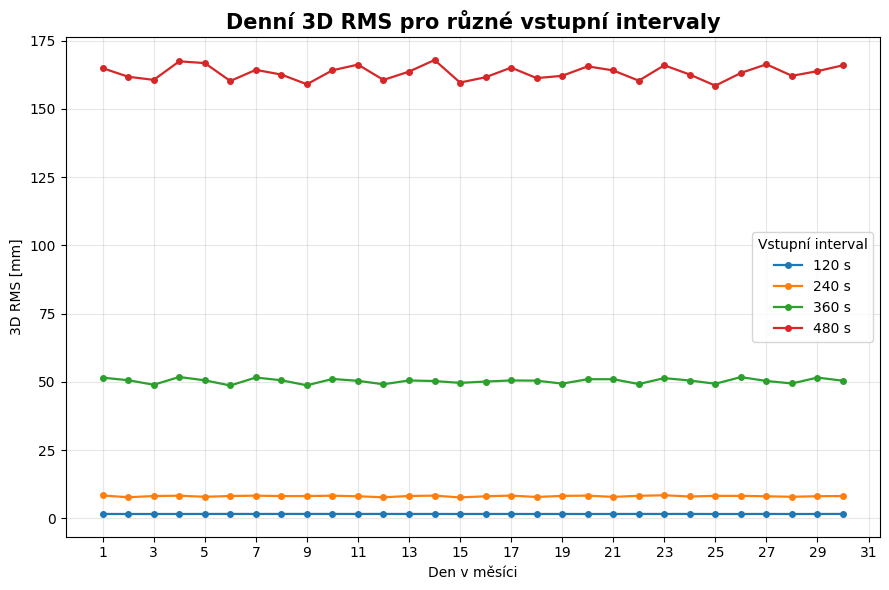

In [17]:
results_df["d3_rms"] = np.sqrt(
    results_df["R_rms"]**2 +
    results_df["T_rms"]**2 +
    results_df["N_rms"]**2
)

results_df["interval_s"] = results_df["keep_every"] * 60

# day of month
results_df["day_num"] = pd.to_datetime(results_df["day"]).dt.day

fig, ax = plt.subplots(figsize=(9, 6))

# sort intervals so the legend makes sense
for interval_s in sorted(results_df["interval_s"].unique()):
    grp = results_df[results_df["interval_s"] == interval_s].copy()
    grp = grp.sort_values("day")

    ax.plot(
        grp["day_num"],
        grp["d3_rms"] * 1000,
        "o-",
        linewidth=1.6,
        markersize=4,
        label=f"{interval_s} s"
    )

# popisy
ax.set_xlabel("Den v měsíci")
ax.set_ylabel("3D RMS [mm]")

ax.set_title("Denní 3D RMS pro různé vstupní intervaly", fontsize=15,  fontweight="bold")

# cleaner x axis (avoid clutter)
ax.set_xticks(np.arange(1, 32, 2))

# minor readability improvement
ax.grid(True, alpha=0.3)

# legenda
ax.legend(title="Vstupní interval", loc="best")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "Daily_3D_RMS_over_time.pdf", bbox_inches="tight")
plt.show()

## RTN stats by keep every

In [18]:
table = []

for keep_every in KEEP_EVERY_LIST:
    R_all = []
    T_all = []
    N_all = []

    for (day, k), diff in results.items():
        if k == keep_every:
            for i in range(len(diff)):
                R_all.append(diff["dR_m"].iloc[i])
                T_all.append(diff["dT_m"].iloc[i])
                N_all.append(diff["dN_m"].iloc[i])

    if len(R_all) > 0:
        R = np.array(R_all)
        T = np.array(T_all)
        N = np.array(N_all)

        R_mean = R.mean()
        T_mean = T.mean()
        N_mean = N.mean()

        R_rms = np.sqrt(np.mean(R**2))
        T_rms = np.sqrt(np.mean(T**2))
        N_rms = np.sqrt(np.mean(N**2))

        R_rms0 = np.sqrt(np.mean((R - R_mean)**2))
        T_rms0 = np.sqrt(np.mean((T - T_mean)**2))
        N_rms0 = np.sqrt(np.mean((N - N_mean)**2))

        d3_rms = np.sqrt(R_rms**2 + T_rms**2 + N_rms**2)

        table.append([
            keep_every,
            keep_every * 60,
            R_mean,
            T_mean,
            N_mean,
            R_rms,
            T_rms,
            N_rms,
            R_rms0,
            T_rms0,
            N_rms0,
            d3_rms
        ])

total_stats_df = pd.DataFrame(table, columns=[
    "keep_every",
    "interval_s",
    "R_mean",
    "T_mean",
    "N_mean",
    "R_rms",
    "T_rms",
    "N_rms",
    "R_rms0",
    "T_rms0",
    "N_rms0",
    "d3_rms"
])

display(total_stats_df)

,keep_every,interval_s,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0,d3_rms
0,2,120,-0.00009,-0.00000,0.00000,0.00038,0.00155,0.00037,0.00037,0.00155,0.00037,0.00164
1,4,240,-0.00032,0.00003,0.00000,0.00569,0.00559,0.00172,0.00568,0.00559,0.00172,0.00816
2,6,360,-0.00056,0.00026,0.00019,0.03596,0.03353,0.01091,0.03595,0.03353,0.01091,0.05036
3,8,480,-0.00136,0.00068,-0.00026,0.11594,0.10928,0.03563,0.11593,0.10927,0.03563,0.16325


In [19]:
df_latex = total_stats_df.copy()

# convert to mm
for col in ["R_rms", "T_rms", "N_rms", "d3_rms"]:
    df_latex[col] = df_latex[col] * 1000

# keep only relevant columns
df_latex = df_latex[[
    "interval_s",
    "R_rms",
    "T_rms",
    "N_rms",
    "d3_rms"
]]

# rename columns (LaTeX-friendly)
df_latex.columns = [
    "Interval [s]",
    "R RMS [mm]",
    "T RMS [mm]",
    "N RMS [mm]",
    "3D RMS [mm]"
]

# round values
df_latex = df_latex.round(3)

display(df_latex)

,Interval [s],R RMS [mm],T RMS [mm],N RMS [mm],3D RMS [mm]
0,120,0.37800,1.55200,0.36900,1.63900
1,240,5.69000,5.58800,1.72500,8.15900
2,360,35.95700,33.53000,10.91000,50.36000
3,480,115.93600,109.27500,35.63200,163.25400


In [20]:
from doris.output.tables import Col, save_latex_table

df_latex = total_stats_df.copy()

# convert to mm
for col in ["R_rms", "T_rms", "N_rms", "d3_rms"]:
    df_latex[col] = df_latex[col] * 1000

df_latex = df_latex.sort_values("interval_s")

_ = save_latex_table(
    df_latex,
    TABLES_DIR / "interp_accuracy.tex",
    cols=[
        Col("interval_s", "Interval [s]", 0),
        Col("R_rms", "R [mm]", 3),
        Col("T_rms", "T [mm]", 3),
        Col("N_rms", "N [mm]", 3),
        Col("d3_rms", "3D RMS [mm]", 3),
    ],
    caption="Souhrnné statistiky interpolační chyby pro různé vstupní intervaly",
    label="tab:interp_accuracy",
    font_size="\\small",
    print_preview=True,
)

\begin{table}[H]
\centering
\small
\caption{Souhrnné statistiky interpolační chyby pro různé vstupní intervaly}
\label{tab:interp_accuracy}
\begin{tabular}{rrrrr}
\toprule
Interval [s] & R [mm] & T [mm] & N [mm] & 3D RMS [mm] \\
\midrule
120 & 0.378 & 1.552 & 0.369 & 1.639 \\
240 & 5.690 & 5.588 & 1.725 & 8.159 \\
360 & 35.957 & 33.530 & 10.910 & 50.360 \\
480 & 115.936 & 109.275 & 35.632 & 163.254 \\
\bottomrule
\end{tabular}
\end{table}



## RTN RMS vs interval

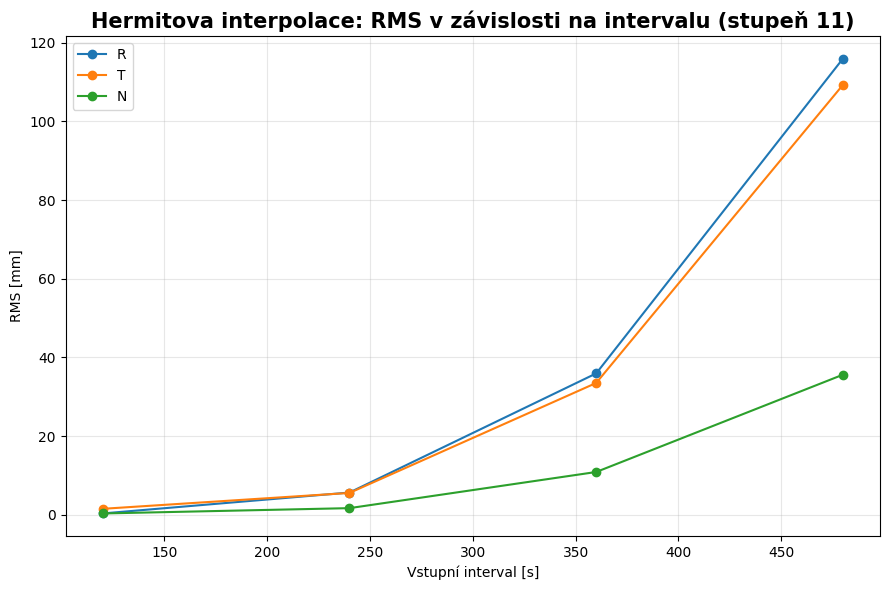

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(total_stats_df["interval_s"], total_stats_df["R_rms"] * 1000, "o-", label="R")
ax.plot(total_stats_df["interval_s"], total_stats_df["T_rms"] * 1000, "o-", label="T")
ax.plot(total_stats_df["interval_s"], total_stats_df["N_rms"] * 1000, "o-", label="N")

ax.set_xlabel("Vstupní interval [s]")
ax.set_ylabel("RMS [mm]")
ax.set_title(f"Hermitova interpolace: RMS v závislosti na intervalu (stupeň {HERMITE_DEGREE})", fontsize=15,  fontweight="bold")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RMS_RTN_vs_interval.pdf", bbox_inches="tight")
plt.show()

## 3D RMS vs interval

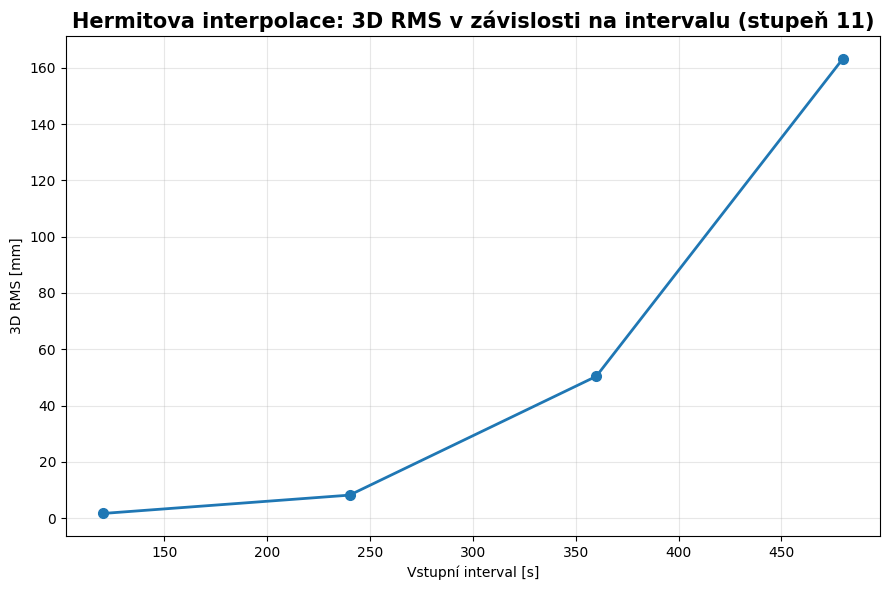

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    total_stats_df["interval_s"],
    total_stats_df["d3_rms"]*1000,
    "o-",
    linewidth=2,
    markersize=7,
)

ax.set_xlabel("Vstupní interval [s]")
ax.set_ylabel("3D RMS [mm]")
ax.set_title(f"Hermitova interpolace: 3D RMS v závislosti na intervalu (stupeň {HERMITE_DEGREE})", fontsize=15,  fontweight="bold")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RMS_3D_vs_interval.pdf", bbox_inches="tight")
plt.show()

## 3D error boxplot

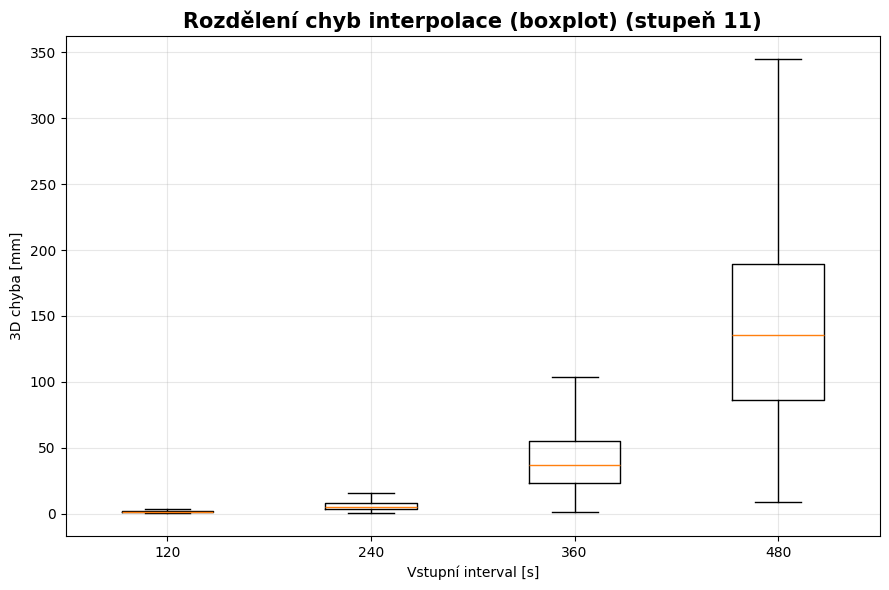

In [23]:
intervals = []
data = []

for keep_every in KEEP_EVERY_LIST:
    all_errors = []

    for (day, k), diff in results.items():
        if k == keep_every:
            for i in range(len(diff)):
                all_errors.append(diff["norm_m"].iloc[i] * 1000)  # mm

    if len(all_errors) > 0:
        intervals.append(keep_every * 60)
        data.append(all_errors)
fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    data,
    tick_labels=[str(i) for i in intervals],
    showfliers=False  # skryje extrémy
)

# ax.set_yscale("log")

ax.set_xlabel("Vstupní interval [s]")
ax.set_ylabel("3D chyba [mm]")
ax.set_title(f"Rozdělení chyb interpolace (boxplot) (stupeň {HERMITE_DEGREE})", fontsize=15,  fontweight="bold")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "Boxpolt.pdf", bbox_inches="tight")
plt.show()

## Estimate 3D RMS for 60 s

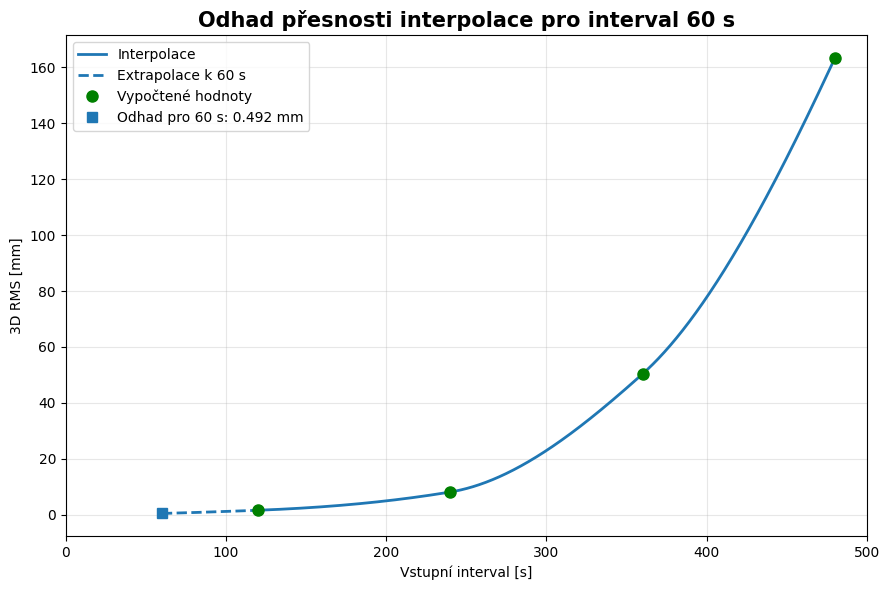

In [24]:
try:
    from scipy.interpolate import PchipInterpolator
except ImportError as e:
    raise RuntimeError("Missing dependency: 'scipy'. Install it with:\n  pip install scipy") from e

# Data for the curve
x = total_stats_df["interval_s"].to_numpy(dtype=float)
y = total_stats_df["d3_rms"].to_numpy(dtype=float) * 1000  # mm

# Safety filter
mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Sort by interval
order = np.argsort(x)
x = x[order]
y = y[order]

# Helper point: zero interval -> zero interpolation error
x_fit = np.r_[0.0, x]
y_fit = np.r_[0.0, y]

pchip = PchipInterpolator(x_fit, y_fit)

x_est = 60.0
y_est = float(pchip(x_est))

# Plot curve only from 60 s
x_plot = np.linspace(x_est, x.max(), 1000)
y_plot = pchip(x_plot)

fig, ax = plt.subplots(figsize=(9, 6))

line_color = "#1f77b4"

# Split curve into extrapolation and interpolation parts
mask_extra = x_plot < x.min()
mask_interp = x_plot >= x.min()

# Interpolation part
ax.plot(
    x_plot[mask_interp],
    y_plot[mask_interp],
    "-",
    linewidth=2,
    color=line_color,
    label="Interpolace",
)

# Extrapolation part
ax.plot(
    x_plot[mask_extra],
    y_plot[mask_extra],
    "--",
    linewidth=2,
    color=line_color,
    label="Extrapolace k 60 s",
)

# Computed values
ax.plot(
    x,
    y,
    "o",
    markersize=8,
    color="green",
    label="Vypočtené hodnoty",
)

# Estimated 60 s value
ax.plot(
    x_est,
    y_est,
    "s",
    markersize=7,
    color=line_color,
    label=f"Odhad pro 60 s: {y_est:.3f} mm",
)

ax.set_xlim(0, x.max() + 20)

ax.set_xlabel("Vstupní interval [s]")
ax.set_ylabel("3D RMS [mm]")
ax.set_title("Odhad přesnosti interpolace pro interval 60 s", fontsize=15,  fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "RMS_3D_vs_interval_estimate_60s.pdf", bbox_inches="tight")
plt.show()